# D4 Better Reward Experiment vs D3 v9 Fresh-RL

Comparing the "crossover" pattern: B4 leads early, MAIN overtakes later.

| | D3 v9 | D4 Better Reward |
|---|---|---|
| Policy | Qwen3-30B | Qwen3-235B |
| Grader | Qwen3-30B (+ 235B for SA) | Qwen3-235B |
| Signals | 10 signals, 1-5 scale | 8 signals, 1-10 scale |
| Goal | TTT-Discover (ML research) | FoundOpt (optimization theory) |
| Fresh context | Yes (buffer context) | No (isolated RL) |

In [10]:
import json
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

ROOT = Path('/home/silas/co-scientist-project')

def load_metrics(path):
    with open(path) as f:
        return [json.loads(l) for l in f if l.strip()]

# D4 Better Reward runs
d4_main = load_metrics(ROOT / 'projects/grant_proposal/runs/2026_04_20_better_reward_MAIN/metrics.jsonl')
d4_b4 = load_metrics(ROOT / 'projects/grant_proposal/runs/2026_04_20_better_reward_B4/metrics.jsonl')

# D3 v9 Fresh-RL runs
d3_main = load_metrics(ROOT / 'projects/ttt_discover/runs/2026_04_18_v9_fresh_bon1/MAIN_fresh_bon1/metrics.jsonl')
d3_b4 = load_metrics(ROOT / 'projects/ttt_discover/runs/2026_04_18_v9_fresh_bon1/B4_bon1/metrics.jsonl')

print(f'D4 MAIN: {len(d4_main)} iters, D4 B4: {len(d4_b4)} iters')
print(f'D3 MAIN: {len(d3_main)} iters, D3 B4: {len(d3_b4)} iters')

D4 MAIN: 27 iters, D4 B4: 27 iters
D3 MAIN: 25 iters, D3 B4: 25 iters


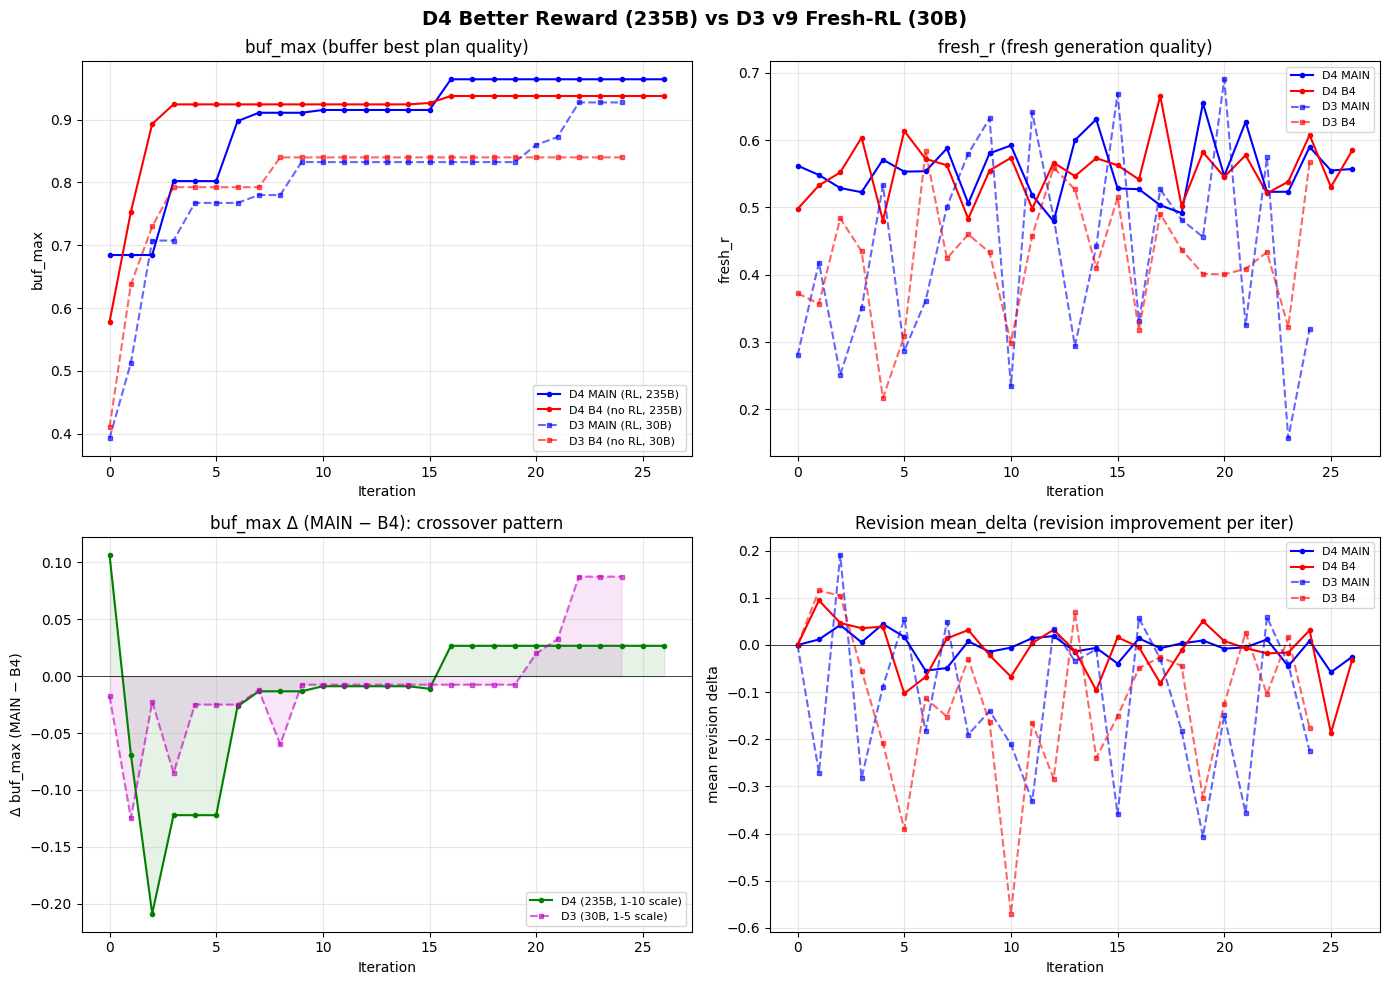

In [11]:
def extract(data, key):
    return [m['iter'] for m in data], [m.get(key, 0) for m in data]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('D4 Better Reward (235B) vs D3 v9 Fresh-RL (30B)', fontsize=14, fontweight='bold')

# --- buf_max ---
ax = axes[0, 0]
ax.set_title('buf_max (buffer best plan quality)')
x, y = extract(d4_main, 'reward/buffer_max'); ax.plot(x, y, 'b-o', ms=3, label='D4 MAIN (RL, 235B)')
x, y = extract(d4_b4, 'reward/buffer_max'); ax.plot(x, y, 'r-o', ms=3, label='D4 B4 (no RL, 235B)')
x, y = extract(d3_main, 'reward/buffer_max'); ax.plot(x, y, 'b--s', ms=3, alpha=0.6, label='D3 MAIN (RL, 30B)')
x, y = extract(d3_b4, 'reward/buffer_max'); ax.plot(x, y, 'r--s', ms=3, alpha=0.6, label='D3 B4 (no RL, 30B)')
ax.set_xlabel('Iteration'); ax.set_ylabel('buf_max')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# --- fresh_r ---
ax = axes[0, 1]
ax.set_title('fresh_r (fresh generation quality)')
x, y = extract(d4_main, 'fresh/reward_mean'); ax.plot(x, y, 'b-o', ms=3, label='D4 MAIN')
x, y = extract(d4_b4, 'fresh/reward_mean'); ax.plot(x, y, 'r-o', ms=3, label='D4 B4')
x, y = extract(d3_main, 'fresh/reward_mean'); ax.plot(x, y, 'b--s', ms=3, alpha=0.6, label='D3 MAIN')
x, y = extract(d3_b4, 'fresh/reward_mean'); ax.plot(x, y, 'r--s', ms=3, alpha=0.6, label='D3 B4')
ax.set_xlabel('Iteration'); ax.set_ylabel('fresh_r')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# --- buf_max delta (MAIN - B4) ---
ax = axes[1, 0]
ax.set_title('buf_max Δ (MAIN − B4): crossover pattern')
n = min(len(d4_main), len(d4_b4))
d4_delta = [d4_main[i]['reward/buffer_max'] - d4_b4[i]['reward/buffer_max'] for i in range(n)]
n3 = min(len(d3_main), len(d3_b4))
d3_delta = [d3_main[i]['reward/buffer_max'] - d3_b4[i]['reward/buffer_max'] for i in range(n3)]
ax.plot(range(n), d4_delta, 'g-o', ms=3, label='D4 (235B, 1-10 scale)')
ax.plot(range(n3), d3_delta, 'm--s', ms=3, alpha=0.6, label='D3 (30B, 1-5 scale)')
ax.axhline(y=0, color='k', linewidth=0.5, linestyle='-')
ax.fill_between(range(n), d4_delta, 0, alpha=0.1, color='g')
ax.fill_between(range(n3), d3_delta, 0, alpha=0.1, color='m')
ax.set_xlabel('Iteration'); ax.set_ylabel('Δ buf_max (MAIN − B4)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# --- revision delta ---
ax = axes[1, 1]
ax.set_title('Revision mean_delta (revision improvement per iter)')
x, y = extract(d4_main, 'revise/mean_delta'); ax.plot(x, y, 'b-o', ms=3, label='D4 MAIN')
x, y = extract(d4_b4, 'revise/mean_delta'); ax.plot(x, y, 'r-o', ms=3, label='D4 B4')
x, y = extract(d3_main, 'revise/mean_delta'); ax.plot(x, y, 'b--s', ms=3, alpha=0.6, label='D3 MAIN')
x, y = extract(d3_b4, 'revise/mean_delta'); ax.plot(x, y, 'r--s', ms=3, alpha=0.6, label='D3 B4')
ax.axhline(y=0, color='k', linewidth=0.5, linestyle='-')
ax.set_xlabel('Iteration'); ax.set_ylabel('mean revision delta')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Detailed Metrics Comparison

In [12]:
from collections import defaultdict

all_runs = {
    'D4 MAIN': d4_main, 'D4 B4': d4_b4,
    'D3 MAIN': d3_main, 'D3 B4': d3_b4,
}

# --- Revision statistics ---
print('=' * 80)
print('REVISION STATISTICS')
print('=' * 80)
print(f'{"Run":12s} | {"Total Rev":>9s} | {"Positive":>8s} | {"Success%":>8s} | {"Avg Δ+":>7s} | {"Avg Δ−":>7s}')
print('-' * 65)

for name, data in all_runs.items():
    total_rev = sum(m.get('revise/count', 0) for m in data)
    total_pos = sum(m.get('revise/n_positive', 0) for m in data)
    rate = total_pos / total_rev if total_rev > 0 else 0
    pos_deltas = [m['revise/mean_delta'] for m in data if m.get('revise/mean_delta', 0) > 0]
    neg_deltas = [m['revise/mean_delta'] for m in data if m.get('revise/mean_delta', 0) < 0]
    avg_pos = np.mean(pos_deltas) if pos_deltas else 0
    avg_neg = np.mean(neg_deltas) if neg_deltas else 0
    print(f'{name:12s} | {total_rev:>9d} | {total_pos:>8d} | {rate:>7.1%} | {avg_pos:>+7.3f} | {avg_neg:>+7.3f}')

# --- Buffer growth ---
print('\n' + '=' * 80)
print('BUFFER GROWTH')
print('=' * 80)
print(f'{"Run":12s} | {"@iter 5":>8s} | {"@iter 10":>8s} | {"@iter 15":>8s} | {"@iter 20":>8s} | {"final":>8s}')
print('-' * 60)
for name, data in all_runs.items():
    sizes = {m['iter']: m.get('buffer/size', 0) for m in data}
    vals = [str(sizes.get(i, '-')) for i in [5, 10, 15, 20]]
    final = sizes.get(max(sizes.keys()), 0)
    print(f'{name:12s} | {vals[0]:>8s} | {vals[1]:>8s} | {vals[2]:>8s} | {vals[3]:>8s} | {final:>8d}')

# --- Beta (KL constraint) evolution ---
print('\n' + '=' * 80)
print('BETA (KL CONSTRAINT) — only relevant for MAIN runs with train_on_fresh')
print('=' * 80)
print(f'{"Run":12s} | {"@iter 0":>8s} | {"@iter 5":>8s} | {"@iter 10":>8s} | {"@iter 20":>8s} | {"final":>8s}')
print('-' * 60)
for name, data in all_runs.items():
    if 'MAIN' not in name:
        continue
    betas = {m['iter']: m.get('beta', 0) for m in data}
    vals = [f"{betas.get(i, 0):.1f}" for i in [0, 5, 10, 20]]
    final = betas.get(max(betas.keys()), 0)
    print(f'{name:12s} | {vals[0]:>8s} | {vals[1]:>8s} | {vals[2]:>8s} | {vals[3]:>8s} | {final:>8.1f}')

# --- Hard gate stats (D3 only, D4 skipped gates) ---
print('\n' + '=' * 80)
print('HARD GATE PASS RATE')
print('=' * 80)
print('D4 Better Reward: skip_hard_gates=true (all plans pass)')

# Check D3 runs for hard gate data in buffer
for name_prefix, run_dir_pattern in [('D3', 'ttt_discover/runs/2026_04_18_v9_fresh_bon1')]:
    for cond, subdir in [('MAIN', 'MAIN_fresh_bon1'), ('B4', 'B4_bon1')]:
        buf_path = ROOT / f'projects/{run_dir_pattern}/{subdir}/buffer.jsonl'
        if buf_path.exists():
            with open(buf_path) as f:
                buf = [json.loads(l) for l in f if l.strip()]
            total = len(buf)
            passed = sum(1 for e in buf if e.get('hard_gate_passed', True))
            gcm = sum(1 for e in buf if e.get('hard_gate_failed_name') == 'goal_contrast_margin')
            cv = sum(1 for e in buf if e.get('hard_gate_failed_name') == 'claim_verification')
            print(f'{name_prefix} {cond:4s}: {passed}/{total} pass ({passed/total:.0%}), '
                  f'GCM fail={gcm}, CV fail={cv}')
        else:
            print(f'{name_prefix} {cond:4s}: buffer not found')

REVISION STATISTICS
Run          | Total Rev | Positive | Success% |  Avg Δ+ |  Avg Δ−
-----------------------------------------------------------------
D4 MAIN      |       104 |       46 |   44.2% |  +0.016 |  -0.025
D4 B4        |       104 |       54 |   51.9% |  +0.034 |  -0.052
D3 MAIN      |        95 |       39 |   41.1% |  +0.074 |  -0.194
D3 B4        |        96 |       40 |   41.7% |  +0.067 |  -0.177

BUFFER GROWTH
Run          |  @iter 5 | @iter 10 | @iter 15 | @iter 20 |    final
------------------------------------------------------------
D4 MAIN      |       44 |      100 |      140 |      180 |      228
D4 B4        |       44 |      100 |      139 |      179 |      227
D3 MAIN      |       43 |       83 |      123 |      163 |      195
D3 B4        |       44 |       84 |      124 |      164 |      196

BETA (KL CONSTRAINT) — only relevant for MAIN runs with train_on_fresh
Run          |  @iter 0 |  @iter 5 | @iter 10 | @iter 20 |    final
---------------------------

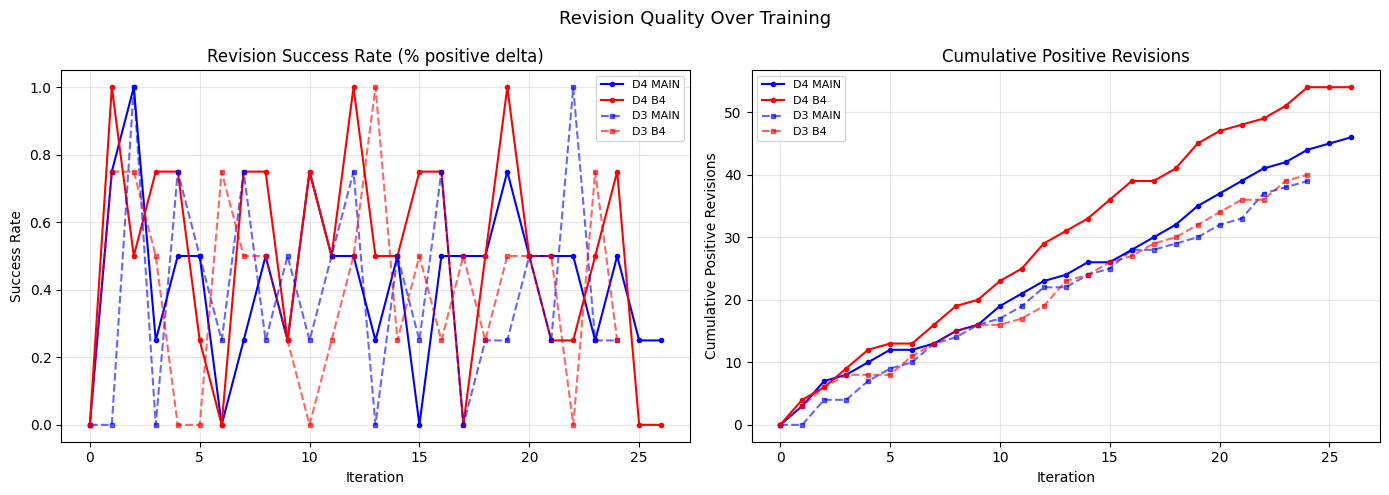

In [13]:
# --- Revision success rate + revision delta over time (2-panel) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Revision Quality Over Training', fontsize=13)

ax = axes[0]
ax.set_title('Revision Success Rate (% positive delta)')
for name, data, color, ls in [('D4 MAIN', d4_main, 'b', '-'), ('D4 B4', d4_b4, 'r', '-'),
                                ('D3 MAIN', d3_main, 'b', '--'), ('D3 B4', d3_b4, 'r', '--')]:
    iters = [m['iter'] for m in data]
    rates = [m['revise/n_positive'] / m['revise/count'] if m.get('revise/count', 0) > 0 else 0 for m in data]
    alpha = 0.6 if 'D3' in name else 1.0
    ax.plot(iters, rates, ls, color=color, alpha=alpha, ms=3, marker='o' if 'D4' in name else 's', label=name)
ax.set_xlabel('Iteration'); ax.set_ylabel('Success Rate')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.set_title('Cumulative Positive Revisions')
for name, data, color, ls in [('D4 MAIN', d4_main, 'b', '-'), ('D4 B4', d4_b4, 'r', '-'),
                                ('D3 MAIN', d3_main, 'b', '--'), ('D3 B4', d3_b4, 'r', '--')]:
    iters = [m['iter'] for m in data]
    cum_pos = np.cumsum([m.get('revise/n_positive', 0) for m in data])
    alpha = 0.6 if 'D3' in name else 1.0
    ax.plot(iters, cum_pos, ls, color=color, alpha=alpha, ms=3, marker='o' if 'D4' in name else 's', label=name)
ax.set_xlabel('Iteration'); ax.set_ylabel('Cumulative Positive Revisions')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# --- Per-signal fresh plan scores (D4 only, from training_logs) ---
def load_logs(path):
    with open(path) as f:
        return [json.loads(l) for l in f if l.strip()]

d4_main_logs = load_logs(ROOT / 'projects/grant_proposal/runs/2026_04_20_better_reward_MAIN/train/training_logs.jsonl')
d4_b4_logs = load_logs(ROOT / 'projects/grant_proposal/runs/2026_04_20_better_reward_B4/train/training_logs.jsonl')

def signal_profile(logs, phase='fresh', iter_range=None):
    items = [l for l in logs if l.get('type') == phase]
    if iter_range:
        items = [l for l in items if iter_range[0] <= l['iter'] <= iter_range[1]]
    out = defaultdict(list)
    for l in items:
        for sid, score in l['signal_vector'].items():
            if score is not None:
                out[sid].append(score)
    return {k: (np.mean(v), np.std(v), len(v)) for k, v in out.items()}

print('=' * 90)
print('D4 PER-SIGNAL FRESH PLAN SCORES (1-10 scale)')
print('=' * 90)

for phase_label, irange in [('Early (iter 0-4)', (0, 4)), ('Late (iter 15-24)', (15, 24))]:
    print(f'\n--- {phase_label} ---')
    m_prof = signal_profile(d4_main_logs, iter_range=irange)
    b_prof = signal_profile(d4_b4_logs, iter_range=irange)
    print(f'{"Signal":28s} | {"MAIN avg±std":>14s} | {"B4 avg±std":>14s} | {"Δ":>6s}')
    print('-' * 70)
    for sid in sorted(m_prof):
        short = sid.split('_', 1)[1][:24]
        m_avg, m_std, _ = m_prof[sid]
        b_avg, b_std, _ = b_prof.get(sid, (0, 0, 0))
        delta = m_avg - b_avg
        marker = ' **' if abs(delta) >= 0.8 else ''
        print(f'  {short:26s} | {m_avg:>5.1f} ± {m_std:>4.1f}   | {b_avg:>5.1f} ± {b_std:>4.1f}   | {delta:>+5.1f}{marker}')

# --- Revision plan scores (what does the buffer look like?) ---
print('\n' + '=' * 90)
print('D4 BUFFER BEST PLAN SIGNAL PROFILE')
print('=' * 90)

for name, log_path in [('MAIN', 'better_reward_MAIN'), ('B4', 'better_reward_B4')]:
    buf_path = ROOT / f'projects/grant_proposal/runs/2026_04_20_{log_path}/buffer.jsonl'
    if buf_path.exists():
        with open(buf_path) as f:
            buf = [json.loads(l) for l in f if l.strip()]
        if buf:
            best = max(buf, key=lambda e: e.get('aggregate_reward', 0))
            print(f'\n{name} best plan (reward={best["aggregate_reward"]:.3f}, iter={best.get("iteration", "?")}):')
            for sid, score in sorted(best.get('signal_vector', {}).items()):
                short = sid.split('_', 1)[1][:24]
                print(f'  {short:26s} = {score}/10')

D4 PER-SIGNAL FRESH PLAN SCORES (1-10 scale)

--- Early (iter 0-4) ---
Signal                       |   MAIN avg±std |     B4 avg±std |      Δ
----------------------------------------------------------------------
  theoretical_novelty        |   7.5 ±  0.7   |   7.5 ±  0.7   |  +0.0
  formalism                  |   2.2 ±  2.1   |   2.3 ±  2.2   |  -0.1
  reasoning_depth            |   8.0 ±  1.1   |   8.2 ±  1.3   |  -0.3
  evidence_rigor             |   3.9 ±  1.9   |   3.6 ±  1.7   |  +0.2
  risk_awareness             |   4.2 ±  2.6   |   3.6 ±  2.9   |  +0.6
  research_focus             |   6.9 ±  1.3   |   6.7 ±  1.4   |  +0.2
  specificity                |   8.2 ±  2.2   |   8.2 ±  1.7   |  +0.1
  arithmetic                 |   7.0 ±  1.4   |   6.4 ±  1.0   |  +0.5

--- Late (iter 15-24) ---
Signal                       |   MAIN avg±std |     B4 avg±std |      Δ
----------------------------------------------------------------------
  theoretical_novelty        |   7.4 ±  0.6   | 

In [15]:
def window_avg(data, key, start, end):
    vals = [m[key] for m in data if start <= m['iter'] <= end]
    return sum(vals)/len(vals) if vals else float('nan')

def crossover_iter(main_data, b4_data, key='reward/buffer_max'):
    """Find first iter where MAIN > B4 after B4 was leading."""
    n = min(len(main_data), len(b4_data))
    b4_led = False
    for i in range(n):
        m = main_data[i][key]
        b = b4_data[i][key]
        if b > m + 0.005:
            b4_led = True
        if b4_led and m > b + 0.005:
            return i
    return None

print('=' * 70)
print(f'{"Metric":35s} {"D3 v9 (30B)":>15s} {"D4 BR (235B)":>15s}')
print('=' * 70)

# Final buf_max
print(f'{"MAIN final buf_max":35s} {d3_main[-1]["reward/buffer_max"]:>15.3f} {d4_main[-1]["reward/buffer_max"]:>15.3f}')
print(f'{"B4 final buf_max":35s} {d3_b4[-1]["reward/buffer_max"]:>15.3f} {d4_b4[-1]["reward/buffer_max"]:>15.3f}')
print(f'{"Δ (MAIN-B4) final":35s} {d3_main[-1]["reward/buffer_max"]-d3_b4[-1]["reward/buffer_max"]:>+15.3f} {d4_main[-1]["reward/buffer_max"]-d4_b4[-1]["reward/buffer_max"]:>+15.3f}')

print()

# Crossover iteration
d3_cross = crossover_iter(d3_main, d3_b4)
d4_cross = crossover_iter(d4_main, d4_b4)
print(f'{"Crossover iter (MAIN overtakes B4)":35s} {str(d3_cross):>15s} {str(d4_cross):>15s}')

# B4 plateau
d3_b4_max = [m['reward/buffer_max'] for m in d3_b4]
d4_b4_max = [m['reward/buffer_max'] for m in d4_b4]

def plateau_iter(buf_max_series, threshold=0.02):
    peak = max(buf_max_series[:10])  # early peak
    for i in range(5, len(buf_max_series)):
        if buf_max_series[i] - peak < threshold:
            continue
        else:
            peak = buf_max_series[i]
    # find first iter that reaches within threshold of final
    final = buf_max_series[-1]
    for i, v in enumerate(buf_max_series):
        if final - v < threshold:
            return i
    return len(buf_max_series) - 1

d3_b4_plat = plateau_iter(d3_b4_max)
d4_b4_plat = plateau_iter(d4_b4_max)
print(f'{"B4 plateau iter":35s} {d3_b4_plat:>15d} {d4_b4_plat:>15d}')
print(f'{"B4 plateau value":35s} {d3_b4_max[d3_b4_plat]:>15.3f} {d4_b4_max[d4_b4_plat]:>15.3f}')

print()

# fresh_r averages
print(f'{"fresh_r avg (first 5 iter)":35s} {window_avg(d3_main, "fresh/reward_mean", 0, 4):>15.3f} {window_avg(d4_main, "fresh/reward_mean", 0, 4):>15.3f}')
print(f'{"fresh_r avg (last 5 iter)":35s} {window_avg(d3_main, "fresh/reward_mean", 20, 24):>15.3f} {window_avg(d4_main, "fresh/reward_mean", 20, 24):>15.3f}')
d3_fr_delta = window_avg(d3_main, 'fresh/reward_mean', 20, 24) - window_avg(d3_main, 'fresh/reward_mean', 0, 4)
d4_fr_delta = window_avg(d4_main, 'fresh/reward_mean', 20, 24) - window_avg(d4_main, 'fresh/reward_mean', 0, 4)
print(f'{"fresh_r trend (last5 - first5)":35s} {d3_fr_delta:>+15.3f} {d4_fr_delta:>+15.3f}')

print()

# Revision delta averages
print(f'{"MAIN rev_delta avg (first 10)":35s} {window_avg(d3_main, "revise/mean_delta", 1, 10):>15.3f} {window_avg(d4_main, "revise/mean_delta", 1, 10):>15.3f}')
print(f'{"MAIN rev_delta avg (last 10)":35s} {window_avg(d3_main, "revise/mean_delta", 15, 24):>15.3f} {window_avg(d4_main, "revise/mean_delta", 15, 24):>15.3f}')
print(f'{"B4 rev_delta avg (last 10)":35s} {window_avg(d3_b4, "revise/mean_delta", 15, 24):>15.3f} {window_avg(d4_b4, "revise/mean_delta", 15, 24):>15.3f}')

Metric                                  D3 v9 (30B)    D4 BR (235B)
MAIN final buf_max                            0.927           0.964
B4 final buf_max                              0.840           0.938
Δ (MAIN-B4) final                            +0.087          +0.027

Crossover iter (MAIN overtakes B4)               20              16
B4 plateau iter                                   8               3
B4 plateau value                              0.840           0.924

fresh_r avg (first 5 iter)                    0.366           0.547
fresh_r avg (last 5 iter)                     0.413           0.562
fresh_r trend (last5 - first5)               +0.047          +0.015

MAIN rev_delta avg (first 10)                -0.107           0.001
MAIN rev_delta avg (last 10)                 -0.163          -0.006
B4 rev_delta avg (last 10)                   -0.096          -0.003


## MAIN_ctx Progress (RL + buffer context for fresh)

Tests hypothesis: RL learns to exploit in-context examples, not domain knowledge.

MAIN_ctx: 1 iters available


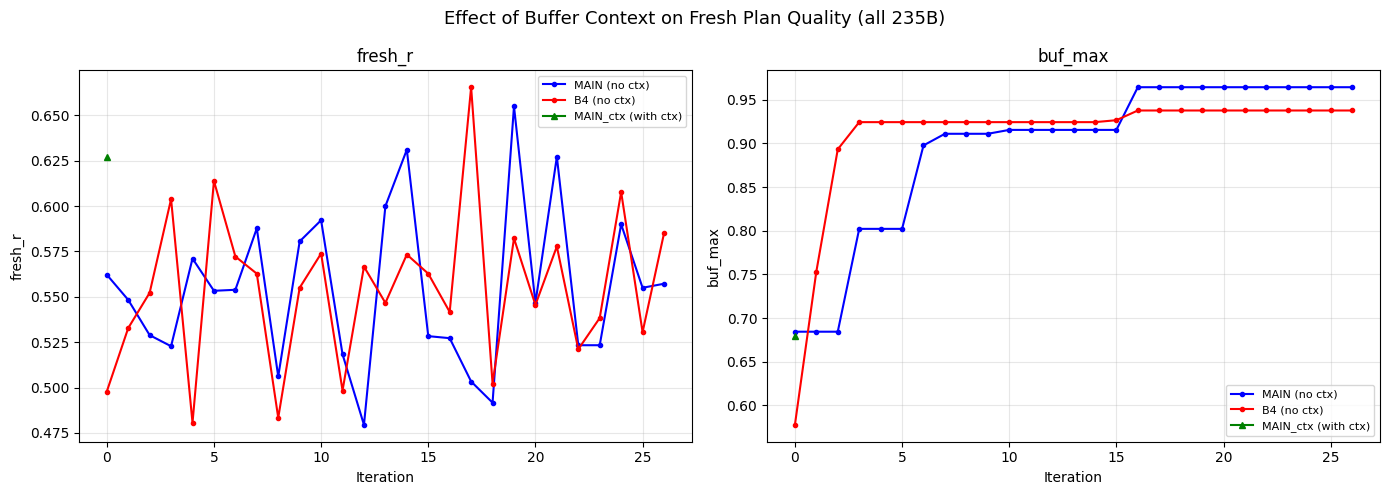

In [16]:
ctx_path = ROOT / 'projects/grant_proposal/runs/2026_04_20_better_reward_MAIN_ctx/metrics.jsonl'
if ctx_path.exists():
    d4_ctx = load_metrics(ctx_path)
    print(f'MAIN_ctx: {len(d4_ctx)} iters available')
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Effect of Buffer Context on Fresh Plan Quality (all 235B)', fontsize=13)
    
    ax = axes[0]
    ax.set_title('fresh_r')
    x, y = extract(d4_main, 'fresh/reward_mean'); ax.plot(x, y, 'b-o', ms=3, label='MAIN (no ctx)')
    x, y = extract(d4_b4, 'fresh/reward_mean'); ax.plot(x, y, 'r-o', ms=3, label='B4 (no ctx)')
    x, y = extract(d4_ctx, 'fresh/reward_mean'); ax.plot(x, y, 'g-^', ms=4, label='MAIN_ctx (with ctx)')
    ax.set_xlabel('Iteration'); ax.set_ylabel('fresh_r')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    
    ax = axes[1]
    ax.set_title('buf_max')
    x, y = extract(d4_main, 'reward/buffer_max'); ax.plot(x, y, 'b-o', ms=3, label='MAIN (no ctx)')
    x, y = extract(d4_b4, 'reward/buffer_max'); ax.plot(x, y, 'r-o', ms=3, label='B4 (no ctx)')
    x, y = extract(d4_ctx, 'reward/buffer_max'); ax.plot(x, y, 'g-^', ms=4, label='MAIN_ctx (with ctx)')
    ax.set_xlabel('Iteration'); ax.set_ylabel('buf_max')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print('MAIN_ctx not available yet — re-run this cell later.')

## Key Findings

| Pattern | D3 v9 (30B) | D4 Better Reward (235B) | Interpretation |
|---------|-------------|------------------------|----------------|
| B4 leads early | ✓ | ✓ | Base model diversity > early RL noise |
| MAIN overtakes | ✓ | ✓ | Revision RL gradually exceeds base model ceiling |
| B4 plateaus | ✓ | ✓ | Fixed policy → fixed revision ceiling |
| fresh_r rises (MAIN) | ✓ (with ctx) | ? (testing MAIN_ctx) | RL may learn to exploit context, not domain knowledge |